In [3]:
import mlflow
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mlflow.set_tracking_uri("sqlite:///mlflow.db")

# Creating a dedicated MLflow Experiment folder in the UI
mlflow.set_experiment("Diabetes_Disease_Progression")

# Load data
diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=42)

2026/03/26 18:17:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/26 18:17:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Manual Run logged successfully. RMSE: 72.38884753363185


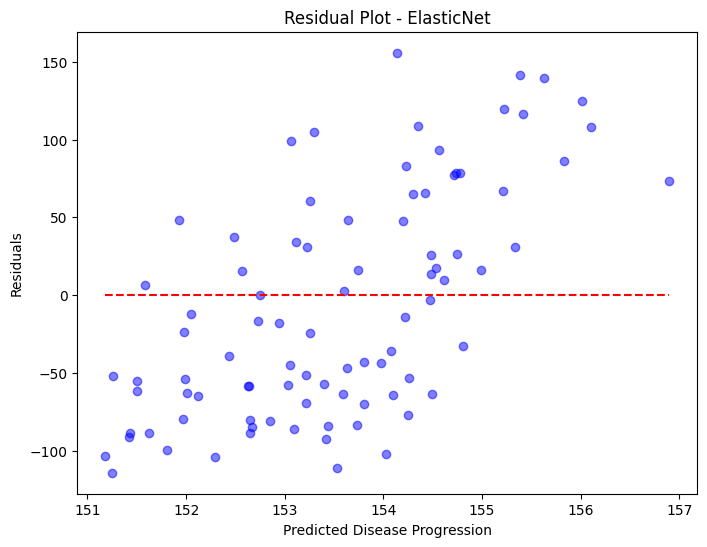

In [4]:
alpha = 0.5
l1_ratio = 0.5

with mlflow.start_run(run_name="ElasticNet_Manual_Tracking"):
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # 1. Manual Parameter & Metric Logging
    mlflow.log_param("alpha", alpha)
    mlflow.log_param("l1_ratio", l1_ratio)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)
    
    # 2. Custom tags for metadata
    mlflow.set_tag("domain", "clinical_healthcare")
    mlflow.set_tag("model_type", "ElasticNet")
    
    # 3. Create and log an artifact (Residual Plot image)
    plt.figure(figsize=(8,6))
    plt.scatter(y_pred, y_test - y_pred, color="blue", alpha=0.5)
    plt.hlines(y=0, xmin=min(y_pred), xmax=max(y_pred), color="red", linestyles="--")
    plt.xlabel("Predicted Disease Progression")
    plt.ylabel("Residuals")
    plt.title("Residual Plot - ElasticNet")
    plt.savefig("residuals.png")
    
    mlflow.log_artifact("residuals.png")
    
    # 4. Log the model manually
    mlflow.sklearn.log_model(model, "elasticnet_model")
    
    print(f"Manual Run logged successfully. RMSE: {rmse}")